<a href="https://colab.research.google.com/github/SharonAwuor/Machine-Learning/blob/main/Machine_not_processed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdurraziq01/cloud-computing-performance-metrics")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cloud-computing-performance-metrics' dataset.
Path to dataset files: /kaggle/input/cloud-computing-performance-metrics


In [2]:
import os

print(path)
print(os.listdir(path))

/kaggle/input/cloud-computing-performance-metrics
['vmCloud_data.csv']


In [3]:
import os
import glob
import pandas as pd

csv_files = glob.glob(os.path.join(path, "*.csv"))

print("CSV files found:")
print(csv_files)

df = pd.read_csv(csv_files[0])

df.head()

CSV files found:
['/kaggle/input/cloud-computing-performance-metrics/vmCloud_data.csv']


,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
0,c5215826-6237-4a33-9312-72c1df909881,2023-01-25 09:10:54,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,2023-01-26 04:46:34,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,io,high,completed
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,2023-01-13 23:39:47,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed
3,e672e32f-c134-4fbc-992b-34eb63bef6bf,2023-02-09 11:45:49,54.488318,88.100960,NaN,195.639954,5876.0,16.456670,0.529511,compute,high,completed
4,f38b8b50-6926-4533-be4f-89ad11624071,2023-06-14 08:27:26,42.365480,NaN,NaN,359.451537,3361.0,55.307992,0.351907,NaN,medium,waiting


In [4]:
print("Rows, Columns:", df.shape)

Rows, Columns: (2000000, 12)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   vm_id                      object 
 1   timestamp                  object 
 2   cpu_usage                  float64
 3   memory_usage               float64
 4   network_traffic            float64
 5   power_consumption          float64
 6   num_executed_instructions  float64
 7   execution_time             float64
 8   energy_efficiency          float64
 9   task_type                  object 
 10  task_priority              object 
 11  task_status                object 
dtypes: float64(7), object(5)
memory usage: 183.1+ MB


In [6]:
df.describe(include='all')

,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
count,1799362,1799334,1.800962e+06,1.799490e+06,1.800519e+06,1.799729e+06,1.800314e+06,1.800173e+06,1.799958e+06,1800038,1800567,1799694
unique,1799362,1708964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3
top,89b1f28f-6134-4ba5-8e9f-8777ba43887a,2023-05-04 16:29:31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,io,medium,waiting
freq,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,600695,600700,600358
mean,NaN,NaN,5.001223e+01,4.998190e+01,5.000076e+02,2.500584e+02,5.001897e+03,4.997133e+01,5.002524e-01,NaN,NaN,NaN
std,NaN,NaN,2.887661e+01,2.885326e+01,2.885793e+02,1.443634e+02,2.885247e+03,2.886130e+01,2.886669e-01,NaN,NaN,NaN
min,NaN,NaN,7.071203e-05,2.516784e-06,1.890490e-04,1.923802e-04,0.000000e+00,1.036192e-06,1.258445e-07,NaN,NaN,NaN
25%,NaN,NaN,2.497675e+01,2.500378e+01,2.500669e+02,1.249695e+02,2.504000e+03,2.497908e+01,2.501631e-01,NaN,NaN,NaN
50%,NaN,NaN,5.005476e+01,4.997609e+01,5.000076e+02,2.502472e+02,5.002000e+03,4.996407e+01,5.003692e-01,NaN,NaN,NaN
75%,NaN,NaN,7.502934e+01,7.495588e+01,7.498175e+02,3.751069e+02,7.502000e+03,7.497650e+01,7.503617e-01,NaN,NaN,NaN


In [7]:
print(df.columns.tolist())

['vm_id', 'timestamp', 'cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption', 'num_executed_instructions', 'execution_time', 'energy_efficiency', 'task_type', 'task_priority', 'task_status']


In [8]:
df.isnull().sum()

,0
vm_id,200638
timestamp,200666
cpu_usage,199038
memory_usage,200510
network_traffic,199481
power_consumption,200271
num_executed_instructions,199686
execution_time,199827
energy_efficiency,200042
task_type,199962


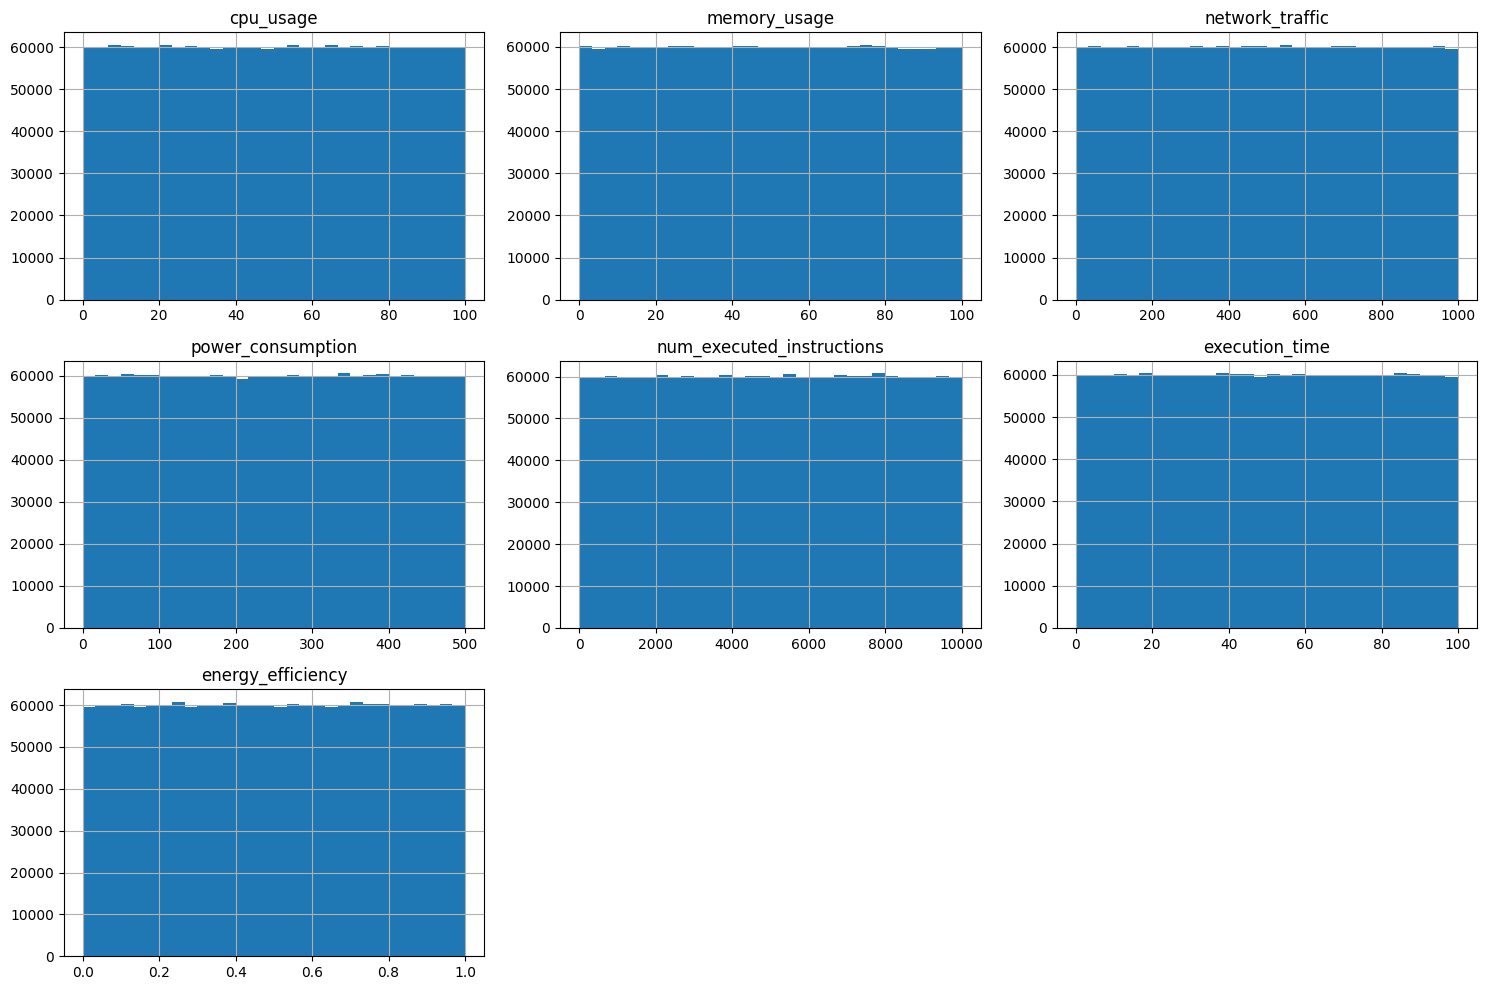

In [9]:
import matplotlib.pyplot as plt

df.hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()

In [10]:
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

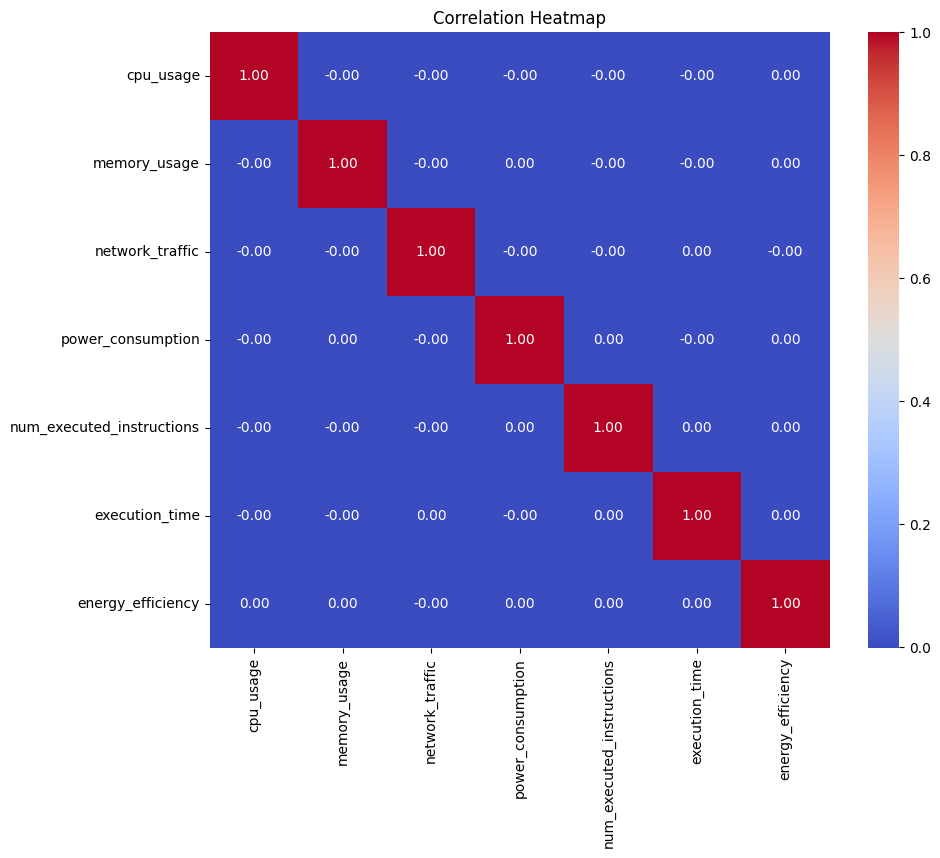

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

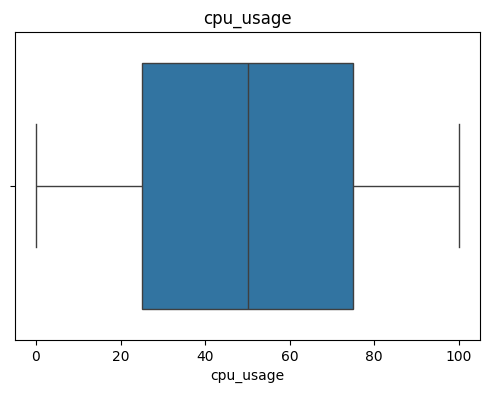

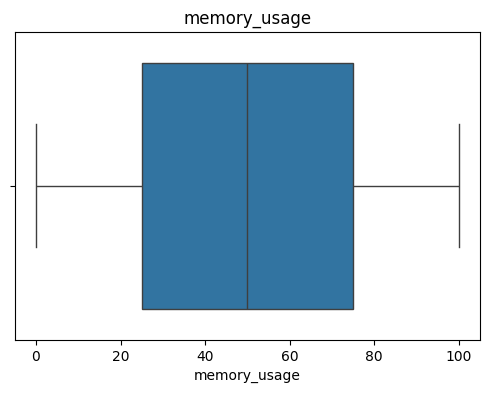

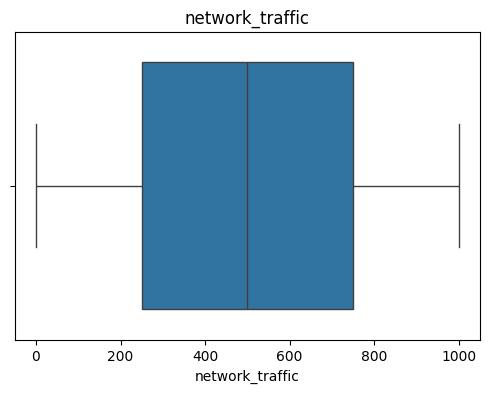

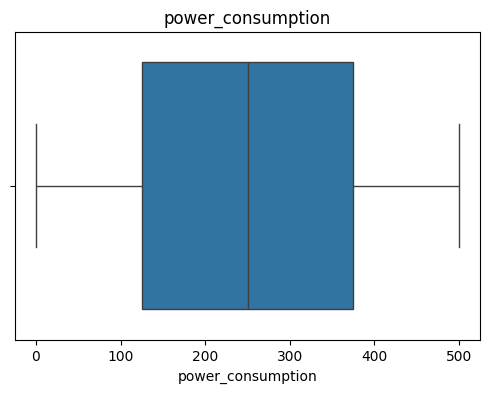

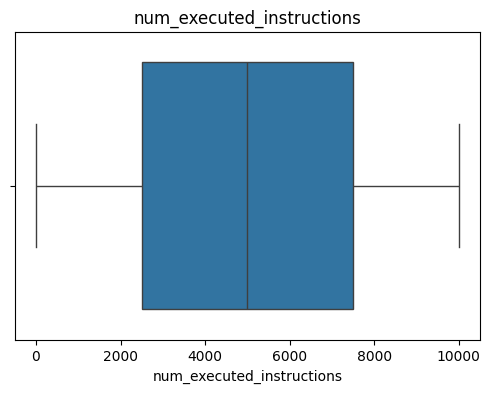

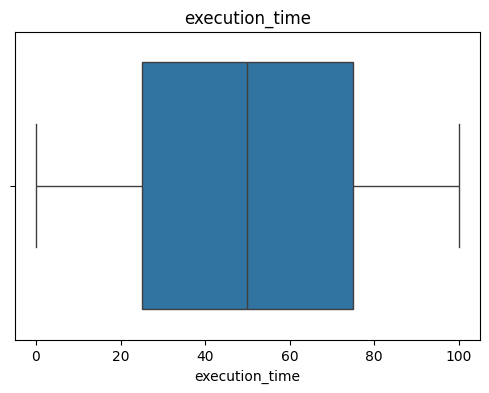

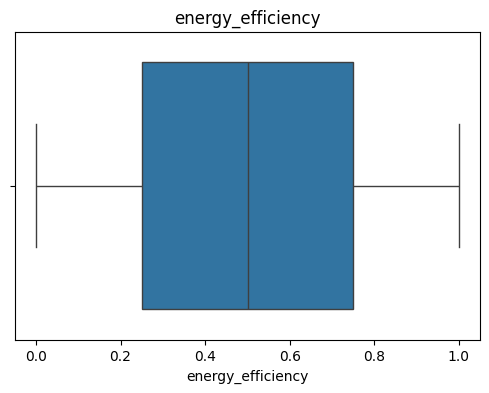

In [12]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

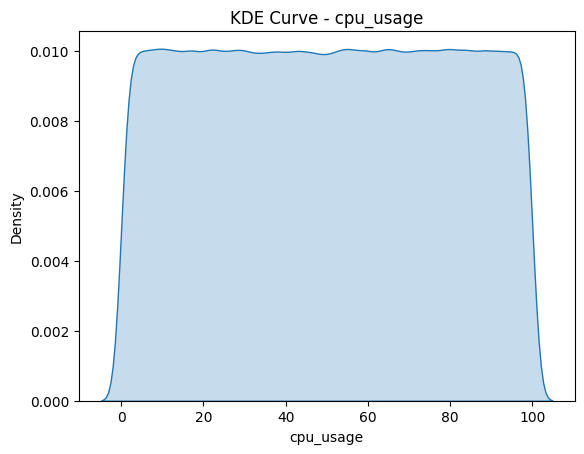

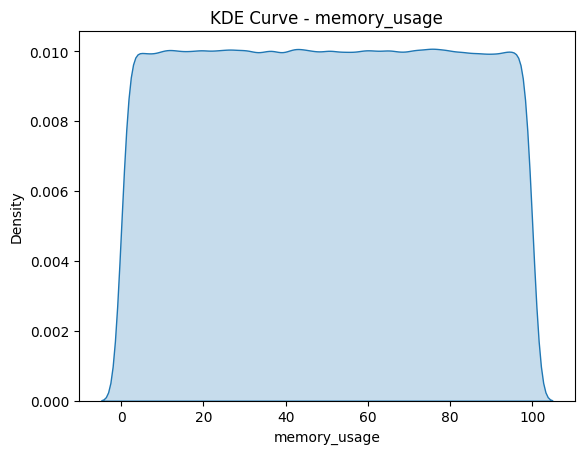

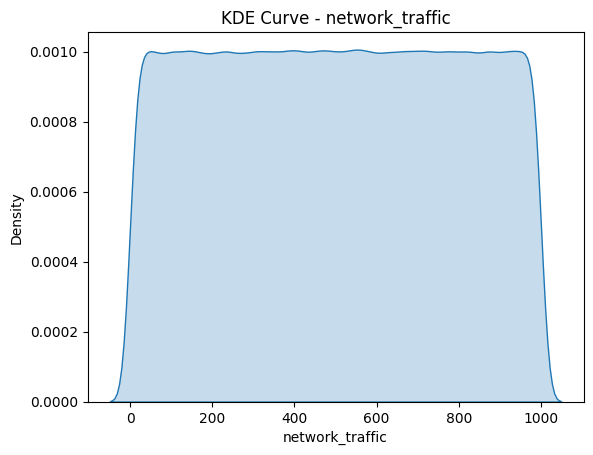

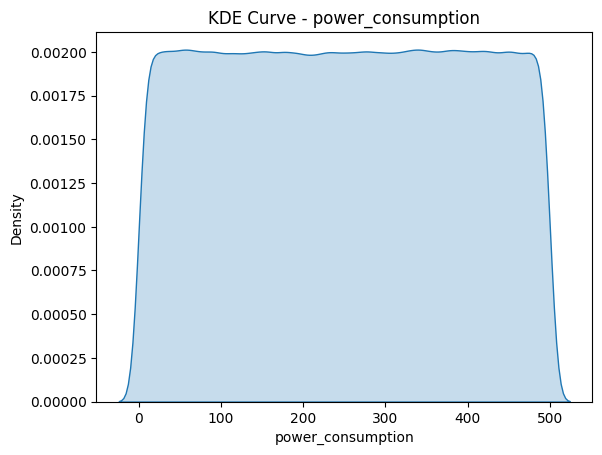

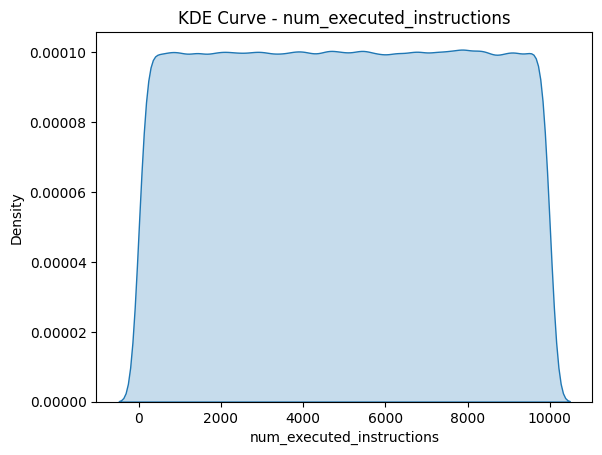

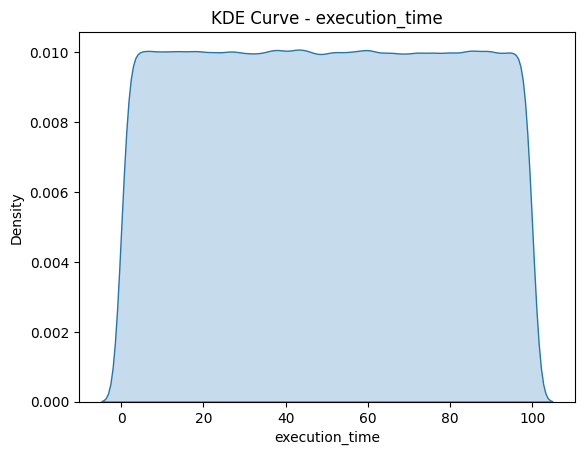

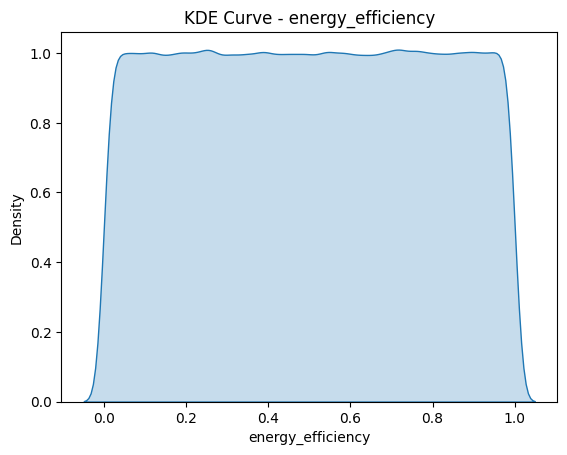

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numerical_cols:
    sns.kdeplot(df[col].dropna(), fill=True)
    plt.title(f"KDE Curve - {col}")
    plt.show()

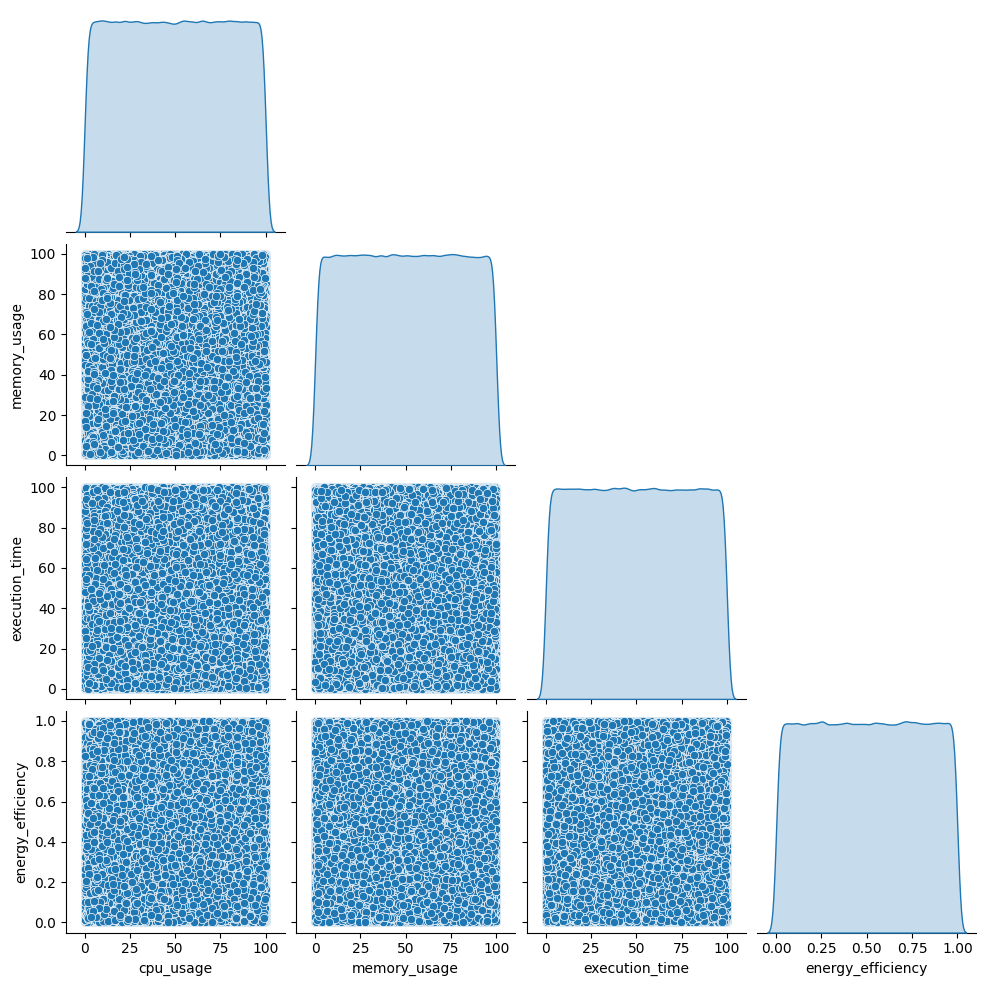

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the columns
numerical_cols = [
    'cpu_usage',
    'memory_usage',
    'execution_time',
    'energy_efficiency'
]

# Draw pairplot
sns.pairplot(
    df[numerical_cols],
    diag_kind='kde',   # KDE curves on the diagonal
    corner=True        # Show only the lower triangle
)

plt.show()